In [1]:
print("Hello, World!")

Hello, World!


In [35]:
from dotenv import load_dotenv
import os
load_dotenv()


True

In [4]:
from langchain_openai import AzureChatOpenAI, AzureOpenAIEmbeddings
embeddings = AzureOpenAIEmbeddings(
    azure_endpoint=os.getenv("AZURE_OPENAI_ENDPOINT"),
    api_key=os.getenv("AZURE_OPENAI_API_KEY"),
    api_version=os.getenv("AZURE_OPENAI_API_VERSION"),
    model=os.getenv("AZURE_OPENAI_EMBEDDING_DEPLOYMENT_NAME")
)
 
llm = AzureChatOpenAI(
    azure_endpoint=os.getenv("AZURE_OPENAI_ENDPOINT"),
    api_key=os.getenv("AZURE_OPENAI_API_KEY"),
    deployment_name=os.getenv("AZURE_OPENAI_DEPLOYMENT_NAME"),
    api_version=os.getenv("AZURE_OPENAI_API_VERSION"),
    max_tokens=500
)

In [6]:
llm.invoke("Hi how are you").content

"Hello! I'm just a computer program, so I don't have feelings, but I'm here and ready to help you. How are you? 😊"

In [7]:
from typing_extensions import TypedDict, Annotated
from langchain_core.messages import AnyMessage, HumanMessage, AIMessage, SystemMessage
import operator

In [8]:
class GraphState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]

In [9]:
{
    "messages": [HumanMessage(content="Hi this is Munavar. Say hello in detail")]
}

{'messages': [HumanMessage(content='Hi this is Munavar. Say hello in detail', additional_kwargs={}, response_metadata={})]}

In [10]:
def llm_call(state: GraphState):
    response = llm.invoke(state['messages'])
    return {
        "messages":[response]
    }

In [11]:
def token_converter(state: GraphState):
    last_msg = state['messages'][-1]
    text = last_msg.content
    token_number = len(text.split())
    summary = f"Total token number in the generated answer (word count) is {token_number}"
    return {
        "messages":[AIMessage(content=summary)]
    }

In [12]:
from langgraph.graph import StateGraph

builder = StateGraph(GraphState)
builder.add_node("llm_call", llm_call)
builder.add_node("token_converter", token_converter)

builder.set_entry_point("llm_call")
builder.add_edge("llm_call","token_converter")
builder.set_finish_point("token_converter")

app = builder.compile()

In [13]:
app.get_graph()

Graph(nodes={'__start__': Node(id='__start__', name='__start__', data=RunnableCallable(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'llm_call': Node(id='llm_call', name='llm_call', data=llm_call(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'token_converter': Node(id='token_converter', name='token_converter', data=token_converter(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), '__end__': Node(id='__end__', name='__end__', data=None, metadata=None)}, edges=[Edge(source='__start__', target='llm_call', data=None, conditional=False), Edge(source='llm_call', target='token_converter', data=None, conditional=False), Edge(source='token_converter', target='__end__', data=None, conditional=False)])

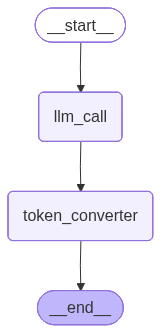

In [14]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [15]:
result = app.invoke({
    "messages": [HumanMessage(content="Hi, this is Sunny. Say hello in detail.")]
})

In [16]:
result

{'messages': [HumanMessage(content='Hi, this is Sunny. Say hello in detail.', additional_kwargs={}, response_metadata={}),
  AIMessage(content="Hello, Sunny! 🌞 It's great to meet you. I hope your day is as bright and cheerful as your name suggests! How are you doing today? Feel free to share anything you'd like to talk about, whether it's plans, questions, or just a casual chat. 😊", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 57, 'prompt_tokens': 18, 'total_tokens': 75, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-11-20', 'system_fingerprint': 'fp_af7f7349a4', 'id': 'chatcmpl-DCg5b3p9PEocHcE9IH9nNsqQxTbSm', 'prompt_filter_results': [{'prompt_index': 0, 'content_filter_results': {'hate': {'filtered': False, 'severity': 'safe'}

In [19]:
for m in result["messages"]:
    print(f"{type(m).__name__}: {m.content}")

HumanMessage: Hi, this is Sunny. Say hello in detail.
AIMessage: Hello, Sunny! 🌞 It's great to meet you. I hope your day is as bright and cheerful as your name suggests! How are you doing today? Feel free to share anything you'd like to talk about, whether it's plans, questions, or just a casual chat. 😊
AIMessage: Total token number in the generated answer (word count) is 46


In [20]:
llm

AzureChatOpenAI(profile={'max_input_tokens': 128000, 'max_output_tokens': 16384, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'structured_output': True, 'image_url_inputs': True, 'pdf_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x0000022FC6C69400>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x0000022FC6C696A0>, root_client=<openai.lib.azure.AzureOpenAI object at 0x0000022FC6A611D0>, root_async_client=<openai.lib.azure.AsyncAzureOpenAI object at 0x0000022FC6A625D0>, model_kwargs={}, openai_api_key=SecretStr('**********'), stream_usage=True, max_tokens=500, disabled_params={'parallel_tool_calls': None}, azure_endpoint='https://moham-mi3bbwt

In [29]:
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

api_wrapper = WikipediaAPIWrapper(top_k_results=5, doc_content_chars_max=500)
wiki_tool = WikipediaQueryRun(api_wrapper=api_wrapper)

In [30]:
wiki_tool.run({"query":"Generative AI"})

'Page: Generative AI pornography\nSummary: Generative AI pornography or simply AI pornography is a digitally created pornography produced through generative artificial intelligence (AI) technologies. Unlike traditional pornography, which involves real actors and cameras, this content is synthesized entirely by AI algorithms. These algorithms, including generative adversarial networks (GANs) and text-to-image models, generate lifelike images, videos, or animations from textual descriptions or datas'

In [37]:
from langchain_community.tools.tavily_search import TavilySearchResults
tool = TavilySearchResults(tavily_api_key=os.getenv("TAVILY_API_KEY"))
tool.invoke({"query":"how is the job market for fresh graduates in 2026?"})

[{'title': 'Worst College-Grad Job Market Predicted for 2026 Amid AI ...',
  'url': 'https://www.linkedin.com/posts/ariannahuffington_its-a-rough-job-market-for-those-just-starting-activity-7403807042215481344-Stfm',
  'content': 'It’s a rough job market for those just starting out. Lindsay Ellis reports in The Wall Street Journal that a survey of employers predicts that 2026 will be the worst college-grad job market in five years. And an August survey by the early-career job-search platform Handshake found that postings for full-time jobs declined more than 16% year-over-year, while each job has an average of 26% more applications. Factors include economic uncertainty, tariffs and, of course, AI. A recent survey by the American Psychological Association found that 57% of adults say the rise of AI is a significant source of stress. The number for students: 78%, nearly double the 45% from last year. It’s clear that AI needs a bigger narrative. CEOs and leaders are all very excited. But 

In [36]:
TAVILY_API_KEY=os.getenv("TAVILY_API_KEY")
TAVILY_API_KEY

'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'

In [38]:
from langchain_community.tools import DuckDuckGoSearchRun
search=DuckDuckGoSearchRun()

search.invoke("what is the latest update on iphone17 release?")

Impersonate 'chrome_100' does not exist, using 'random'


'The iPhone 17 Pro Max release date is the same as the regular version, so fans don’t have to wait longer. ... the latest iPhone, the new iPhone 17 ... CyberIntro is a Web based Tech New Portal focuses on events and updates from Giant Tech Companies like Google, Facebook, Microsoft, Apple, etc., The device runs on iOS 26 , Apple ’ s latest ... The latest iPhone model as of now is the iPhone 15 series, released in September 2024. Ask an AI to put together an image of the new camera bar based on rumours and this is what you get. ... What we do for sure know is what is coming in ... Current industry leaks suggest that Apple is on track to release the iPhone 17 in September 2025 , following its usual annual launch cycle.'

In [39]:
from langchain_community.tools import YouTubeSearchTool

In [40]:
tool = YouTubeSearchTool()

In [41]:
tool.name

'youtube_search'

In [42]:
tool.description

'search for youtube videos associated with a person. the input to this tool should be a comma separated list, the first part contains a person name and the second a number that is the maximum number of video results to return aka num_results. the second part is optional'

In [43]:
tool.run('sunny savitha')

"['https://www.youtube.com/watch?v=7V1w5gnZ-kw&pp=ygUNc3Vubnkgc2F2aXRoYdIHCQmiCgGHKiGM7w%3D%3D', 'https://www.youtube.com/watch?v=_kpxLkH5vY0&pp=ygUNc3Vubnkgc2F2aXRoYQ%3D%3D']"

In [44]:
def multiply(a: int, b: int):
    return a*b

In [45]:
multiply(10,20)

200

In [46]:
multiply.invoke(10,20)

AttributeError: 'function' object has no attribute 'invoke'

In [48]:
from langchain.tools import tool

@tool
def multiply(a: int, b: int)-> int:
    '''this tool is for the multiplication'''
    return a*b

In [50]:
multiply.invoke({"a":10,"b":20})

200

In [51]:
multiply.name

'multiply'

In [52]:
multiply.description

'this tool is for the multiplication'

In [53]:
multiply.args

{'a': {'title': 'A', 'type': 'integer'},
 'b': {'title': 'B', 'type': 'integer'}}

In [54]:
@tool
def get_word_length(word: str) -> int:
    """it is a tool to count the length of the word"""
    return len(word)

In [55]:
get_word_length.invoke("Sam")

3

In [56]:
get_word_length.invoke("Hello world")

11

In [57]:
@tool
def call_gmail_api(args):
    """this is a tool to call gmail api""" 
    pass

In [58]:
import yfinance as yf

In [59]:
@tool
def get_stock_price(ticker:str) -> str: 
    """this is a tool to get stock price using yfinance"""
    try:
        stock = yf.Ticker(ticker)

        # Get last 1 day historical data
        data = stock.history(period="1d")

        if data.empty:
            return f"No data found for ticker '{ticker}'. Please check the symbol."

        latest_close = data["Close"].iloc[-1]

        # Detect currency
        currency = stock.info.get("currency", "")
        symbol_map = {
            "INR": "₹",
            "USD": "$",
            "EUR": "€",
            "GBP": "£"
        }

        symbol = symbol_map.get(currency, "")
        currency_text = currency if currency else ""

        if symbol:
            return f"The last closing price of {ticker.upper()} was {symbol}{latest_close:.2f}."
        else:
            return f"The last closing price of {ticker.upper()} was {latest_close:.2f} {currency_text}."

    except Exception as e:
        return f"An error occurred while fetching stock data: {str(e)}"

In [60]:
get_stock_price.invoke("TCS.NS")

'The last closing price of TCS.NS was ₹2575.20.'

In [61]:
get_stock_price.invoke("AAPL")

'The last closing price of AAPL was $266.18.'

In [62]:
get_stock_price.invoke("TSLA")

'The last closing price of TSLA was $399.83.'

In [63]:
get_stock_price.invoke("HDFCBANK.NS")

'The last closing price of HDFCBANK.NS was ₹913.35.'